<div align="center">

# NYC Citi Bike Demand Forecasting

### *Forecasting Daily Ride Volume with Time-Series Models*

**CUSP-GX 7023 · Applied Data Science · Spring 2026**

**Group: Apex** &nbsp;|&nbsp; Jerry Zhao · Clement Mo · Keyang Yan

</div>

---

# 1. Question & Hypothesis

## 1.1 Background

NYC Citi Bike is the largest public bike-sharing system in the United States. Each trip is recorded with timestamps, station identifiers, and rider categories, making it a strong source for studying **urban mobility** through time-series analysis. Reliable forecasts of daily bike demand have direct value for **fleet rebalancing**, **station-level planning**, and **low-emission transport policy**.

The 6-month raw dataset contains approximately **20 million trip records**, which may exceed the memory limits of a standard laptop if loaded all at once. We therefore use a **chunk-based aggregation pipeline**. For each monthly Citi Bike file, the notebook downloads the official ZIP to a local cache if needed, reads only the columns needed for this project, mainly `started_at` and `member_casual`, processes each CSV in chunks, aggregates rides into daily and hourly counts by user type, and discards raw trip-level rows after aggregation.

The final analysis is based on two compact tables: `daily_usage` and `hourly_usage`, with separate columns for member, casual, and total rides. This greatly reduces memory usage while preserving the information needed for city-wide daily/hourly usage analysis and forecasting.

## 1.2 Main Research Question

> **Can historical Citi Bike trip data be used to forecast future daily ride volume in New York City?**

## 1.3 Hypotheses

| # | Hypothesis |
|:-:|:--|
| **H1** | The series decomposes into a slowly varying **trend**, a **weekly seasonal** component (period = 7), and a residual. |
| **H2** | Weekday usage shows pronounced **morning and evening commute peaks**; weekend usage is flatter and shifts toward midday. |
| **H3** | **Member** rides concentrate on weekday commuting hours; **casual** rides concentrate on weekend afternoons. |
| **H4** | A simple **ARIMA(p, d, q)** model, informed by ACF / PACF diagnostics, outperforms a naive last-day forecast on MAE, MSE, and RMSE. |
| **H5** | A **linear regression** of daily ride counts on calendar features (day-of-week, month, `is_weekend`) and **lag features** (lag-1, lag-7, 7-day rolling mean) also outperforms the naive baseline. |

## 1.4 Scope and Limitations

- **Temporal scope**: Jan 1 – Jun 30, 2025 (NYC only; `JC*` Jersey City files excluded).
- **No exogenous variables**: weather and public-holiday effects are intentionally omitted; the forecasting setup is univariate.
- **Aggregation level**: city-wide daily and hourly counts. Station-level spatial analysis is out of scope.
- **Forecast horizon**: short-term (≤ 30 days). With only 6 months of training data, yearly seasonality cannot be characterized.

## 1.5 Success Criteria

On the held-out test set (**June 2025**), a successful model should:

1. Achieve **lower MAE, MSE, and RMSE** than the naive last-day baseline.
2. Have residuals that show no strong systematic pattern, with most residuals staying within a **±3σ band** and any exceptions explicitly discussed.

Comparing the ARIMA model (**H4**) and the regression model (**H5**), and explaining their respective strengths, is itself part of the analysis.

---

# 2. Data

## Step 0 · Setup & Imports

Standard imports for data handling, visualization, time-series modeling, and regression. Sets a fixed random seed and a project-level `data/` directory.

In [1]:
# ------------------------
# 1. Data handling and visualization
# ------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# 2. Streaming download (Python standard library)
# ------------------------
import io
import zipfile
from urllib.request import urlopen
from pathlib import Path

# ------------------------
# 3. Modeling libraries
# ------------------------
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------
# 4. Display and plotting settings
# ------------------------
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4)

np.random.seed(42)

# ------------------------
# 5. Project paths
# ------------------------
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print('Setup complete.')


Setup complete.


## Step 1 · Load & Aggregate Data

Each monthly ZIP is retrieved from the official Citi Bike S3 bucket and cached locally if it is not already present in `data/`. The notebook then opens every NYC CSV inside the ZIP, skips `JC*` Jersey City files, reads only `started_at` and `member_casual` in chunks, aggregates to daily and hourly ride counts by user type, and discards raw rows immediately after each chunk.

Outputs saved to `data/`: `daily_usage.csv` and `hourly_usage.csv`.


In [2]:
# ------------------------
# 1. Define months and download URL
# ------------------------
months = ['202501', '202502', '202503', '202504', '202505', '202506']
URL = 'https://s3.amazonaws.com/tripdata/{ym}-citibike-tripdata.zip'

# ------------------------
# 2. Download any missing zip files
# ------------------------
for ym in months:
    zip_path = DATA_DIR / f'{ym}-citibike-tripdata.zip'
    if not zip_path.exists():
        print(f'Downloading {ym} ...')
        with urlopen(URL.format(ym=ym)) as response, open(zip_path, 'wb') as out_file:
            out_file.write(response.read())

# ------------------------
# 3. Extract all CSV files from the zips into one folder
# ------------------------
csv_dir = DATA_DIR / 'csv'
csv_dir.mkdir(exist_ok=True)

for ym in months:
    zip_path = DATA_DIR / f'{ym}-citibike-tripdata.zip'
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(csv_dir)

# Get the list of CSV files we want (skip Jersey City files)
csv_files = sorted(p for p in csv_dir.rglob('*.csv') if not p.name.startswith('JC'))
print('Found', len(csv_files), 'CSV files.')

# ------------------------
# 4. Read all CSVs into one DataFrame
# ------------------------
trips = pd.concat(
    [pd.read_csv(p, usecols=['started_at', 'member_casual'], parse_dates=['started_at'])
     for p in csv_files],
    ignore_index=True,
)
trips = trips.dropna(subset=['started_at', 'member_casual'])
trips['date'] = trips['started_at'].dt.date
trips['hour'] = trips['started_at'].dt.hour

print('Total trips loaded:', len(trips))

# ------------------------
# 5. Aggregate to daily and hourly counts
# ------------------------
daily_usage  = trips.groupby(['date', 'member_casual']).size().unstack(fill_value=0)
hourly_usage = trips.groupby(['date', 'hour', 'member_casual']).size().unstack(fill_value=0)

daily_usage['total']  = daily_usage['casual']  + daily_usage['member']
hourly_usage['total'] = hourly_usage['casual'] + hourly_usage['member']

daily_usage  = daily_usage[['casual', 'member', 'total']]
hourly_usage = hourly_usage[['casual', 'member', 'total']]

daily_usage.index  = pd.to_datetime(daily_usage.index)
daily_usage.index.name = 'date'

# ------------------------
# 6. Save to CSV
# ------------------------
daily_usage.to_csv(DATA_DIR / 'daily_usage.csv')
hourly_usage.to_csv(DATA_DIR / 'hourly_usage.csv')

print('daily_usage  shape:', daily_usage.shape)
print('hourly_usage shape:', hourly_usage.shape)
print(daily_usage.head())


Found 24 CSV files.
Total trips loaded: 20133497
daily_usage  shape: (183, 3)
hourly_usage shape: (4358, 3)
member_casual  casual  member  total
date                                
2024-12-30          0       1      1
2024-12-31         92     114    206
2025-01-01      10915   40527  51442
2025-01-02       8454   63325  71779
2025-01-03       9028   66333  75361


# 3. Descriptive Analysis

## Step 2 · Data Cleaning & Validation

Load the aggregated CSVs from disk, filter to Jan 1 – Jun 30 2025, and check for missing dates, zero-ride days, and outliers.

In [3]:
# ------------------------
# 1. Load CSVs from disk
# ------------------------
daily  = pd.read_csv(DATA_DIR / 'daily_usage.csv',  index_col=0, parse_dates=True)
hourly = pd.read_csv(DATA_DIR / 'hourly_usage.csv', index_col=[0, 1], parse_dates=['date'])

rows_before = len(daily)

# ------------------------
# 2. Filter to 2025-01-01 ~ 2025-06-30
# ------------------------
daily  = daily.loc['2025-01-01':'2025-06-30']

hourly_dates = hourly.index.get_level_values('date')
hourly = hourly[(hourly_dates >= '2025-01-01') & (hourly_dates <= '2025-06-30')]

rows_after = len(daily)

# ------------------------
# 3. Check for missing dates
# ------------------------
full_range    = pd.date_range('2025-01-01', '2025-06-30', freq='D')
missing_dates = full_range.difference(daily.index)

# ------------------------
# 4. Check for zero-ride days
# ------------------------
zero_days = daily[daily['total'] == 0]

# ------------------------
# 5. Check for outliers (beyond ±3 standard deviations)
# ------------------------
mean_total   = daily['total'].mean()
std_total    = daily['total'].std()
upper_bound  = mean_total + 3 * std_total
lower_bound  = mean_total - 3 * std_total
outlier_days = daily[(daily['total'] > upper_bound) | (daily['total'] < lower_bound)]

# ------------------------
# 6. Print summary
# ------------------------
print('Rows before filter :', rows_before)
print('Rows after filter  :', rows_after)
print('Missing dates      :', len(missing_dates))
if len(missing_dates) > 0:
    print('  Dates:', list(missing_dates.date))
print('Zero-ride days     :', len(zero_days))
print('Outlier days (±3σ) :', len(outlier_days))
if len(outlier_days) > 0:
    print(outlier_days[['total']])

print('\nCleaning complete.')


Rows before filter : 183
Rows after filter  : 181
Missing dates      : 0
Zero-ride days     : 0
Outlier days (±3σ) : 0

Cleaning complete.


## Step 3 · Basic Statistics

Check the shape, date range, data types, and summary statistics of the daily dataset.

In [4]:
# ------------------------
# 1. Shape and date range
# ------------------------
print('Shape:', daily.shape)
print('Date range:', daily.index.min().date(), 'to', daily.index.max().date())
print()

# ------------------------
# 2. Data types
# ------------------------
print('Data types:')
print(daily.dtypes)
print()

# ------------------------
# 3. Descriptive statistics
# ------------------------
print('Descriptive statistics:')
print(daily.describe().round(0))


Shape: (181, 3)
Date range: 2025-01-01 to 2025-06-30

Data types:
casual    int64
member    int64
total     int64
dtype: object

Descriptive statistics:
         casual     member      total
count    181.00     181.00     181.00
mean  17,962.00  93,272.00 111,234.00
std   12,268.00  32,009.00  42,181.00
min    2,453.00  26,548.00  29,813.00
25%    7,486.00  66,333.00  75,361.00
50%   13,913.00  91,697.00 108,268.00
75%   27,281.00 116,058.00 148,620.00
max   55,500.00 159,978.00 193,279.00


## Step 4 · Member vs Casual Breakdown

Compare the total number of rides by user type over the full Jan–Jun 2025 period.

Total member rides: 16882179
Total casual rides: 3251111


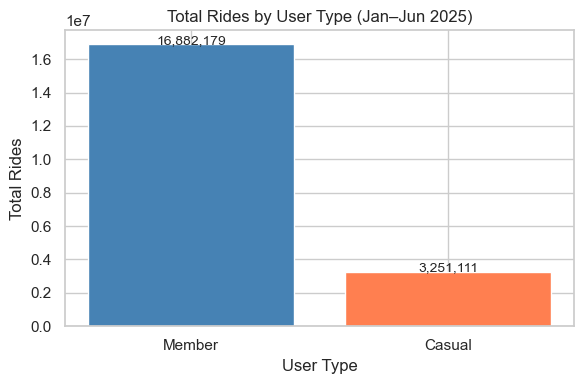

In [5]:
# ------------------------
# 1. Calculate totals
# ------------------------
total_member = daily['member'].sum()
total_casual = daily['casual'].sum()

print('Total member rides:', total_member)
print('Total casual rides:', total_casual)

# ------------------------
# 2. Bar chart
# ------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Member', 'Casual'], [total_member, total_casual], color=['steelblue', 'coral'])
ax.set_title('Total Rides by User Type (Jan–Jun 2025)')
ax.set_ylabel('Total Rides')
ax.set_xlabel('User Type')

# Add value labels on top of bars
ax.text(0, total_member + 50000, f'{total_member:,}', ha='center', fontsize=10)
ax.text(1, total_casual + 50000, f'{total_casual:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## Step 5 · Daily Ride Count Over Time

Line plot of total daily rides and a monthly bar chart to show the seasonal growth trend.

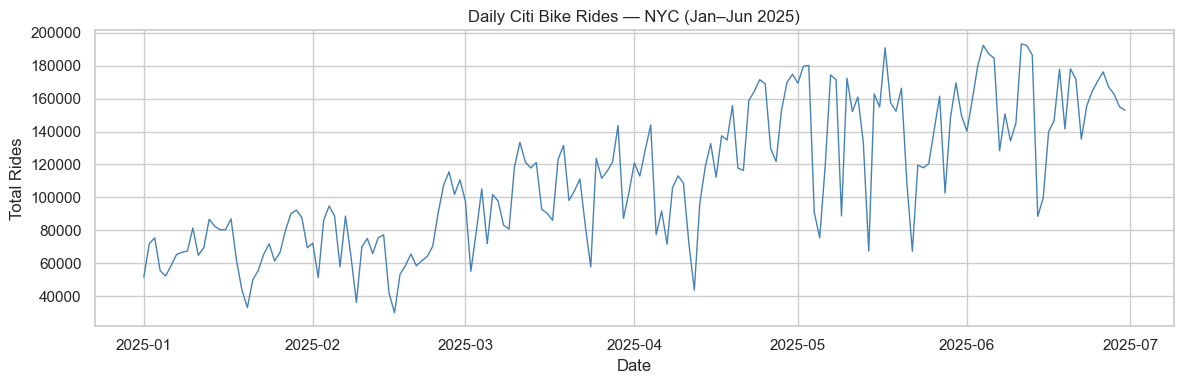

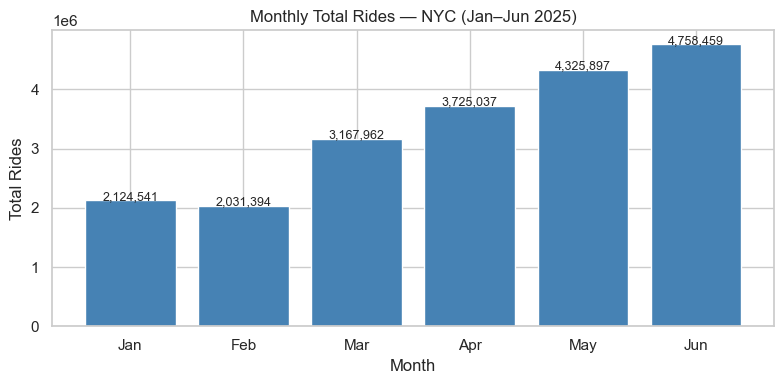

In [6]:
# ------------------------
# 1. Daily total rides line plot
# ------------------------
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["total"], color="steelblue", linewidth=1)
ax.set_title("Daily Citi Bike Rides — NYC (Jan–Jun 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Rides")
plt.tight_layout()
plt.show()

# ------------------------
# 2. Monthly total rides bar chart
# ------------------------
monthly = daily["total"].resample("ME").sum()
month_labels = monthly.index.strftime("%b")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(month_labels, monthly.values, color="steelblue")
ax.set_title("Monthly Total Rides — NYC (Jan–Jun 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Rides")
for i, v in enumerate(monthly.values):
    ax.text(i, v + 10000, f"{v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## Step 5B · Trend, Weekly Seasonality & Residuals

Decompose the daily ride series into a 7-day rolling trend, an average weekday seasonal component, and a residual. This directly checks H1 from the research hypotheses.


Weekly seasonal component:
weekday
Mon    -7,482.00
Tue     9,264.00
Wed     5,403.00
Thu     7,217.00
Fri     8,632.00
Sat    -4,622.00
Sun   -18,518.00
Name: detrended, dtype: float64

Residual mean: 0.0
Residual std : 19599.4


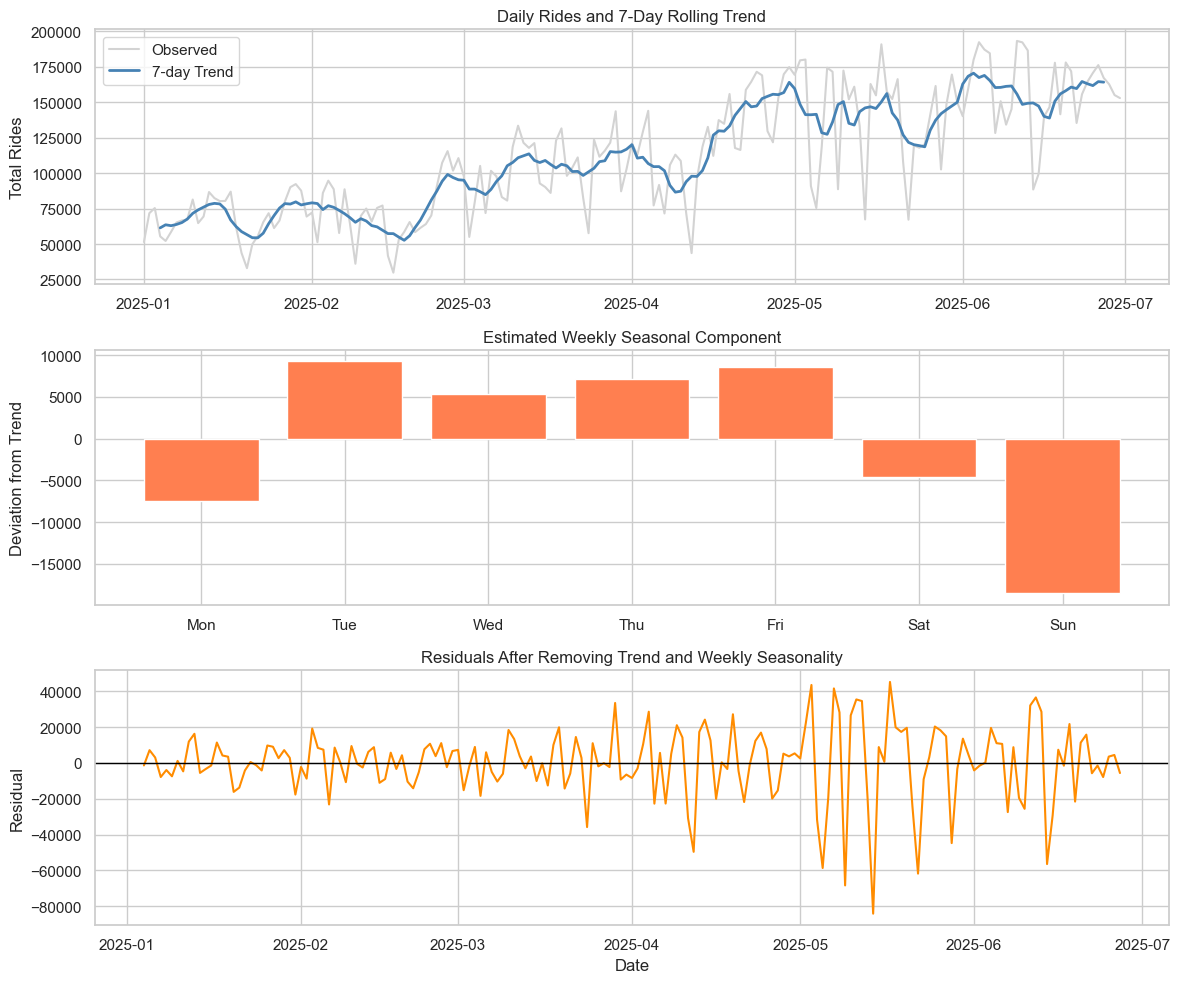

In [7]:
# ------------------------
# 1. Estimate trend with a centered 7-day rolling average
# ------------------------
decomp = daily[["total"]].copy()
decomp["trend_7d"] = decomp["total"].rolling(window=7, center=True).mean()

# ------------------------
# 2. Estimate weekly seasonal component
# ------------------------
decomp["weekday"] = decomp.index.dayofweek
decomp["detrended"] = decomp["total"] - decomp["trend_7d"]
weekly_seasonal = decomp.dropna().groupby("weekday")["detrended"].mean()
decomp["seasonal_weekly"] = decomp["weekday"].map(weekly_seasonal)

# ------------------------
# 3. Calculate residuals
# ------------------------
decomp["residual"] = decomp["total"] - decomp["trend_7d"] - decomp["seasonal_weekly"]

print("Weekly seasonal component:")
print(weekly_seasonal.rename(index={0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}).round(0))
print()
print("Residual mean:", round(decomp["residual"].mean(), 1))
print("Residual std :", round(decomp["residual"].std(), 1))

# ------------------------
# 4. Plot observed series, trend, seasonality, and residuals
# ------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

axes[0].plot(decomp.index, decomp["total"], label="Observed", color="lightgray")
axes[0].plot(decomp.index, decomp["trend_7d"], label="7-day Trend", color="steelblue", linewidth=2)
axes[0].set_title("Daily Rides and 7-Day Rolling Trend")
axes[0].set_ylabel("Total Rides")
axes[0].legend()

axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekly_seasonal.values, color="coral")
axes[1].set_title("Estimated Weekly Seasonal Component")
axes[1].set_ylabel("Deviation from Trend")

axes[2].plot(decomp.index, decomp["residual"], color="darkorange")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Residuals After Removing Trend and Weekly Seasonality")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()


# 4. Exploratory Analysis

## Step 6 · Weekday vs Weekend Usage

Compare average daily rides on weekdays versus weekends.

Average rides on weekdays: 115550.0
Average rides on weekends: 100525.0


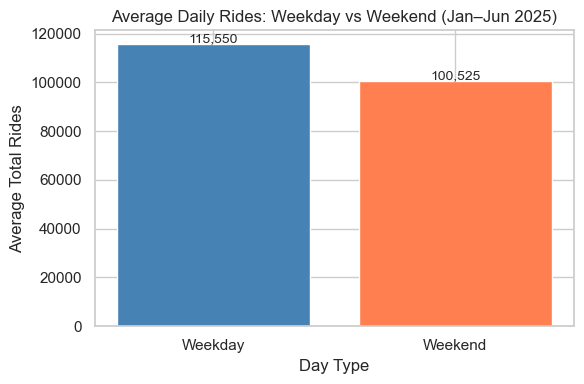

In [8]:
# ------------------------
# 1. Label each day as weekday or weekend
# ------------------------
daily['weekday'] = daily.index.dayofweek  # Monday=0, Sunday=6
daily['is_weekend'] = daily['weekday'] >= 5

# ------------------------
# 2. Calculate average rides
# ------------------------
avg_weekday = daily[daily['is_weekend'] == False]['total'].mean()
avg_weekend = daily[daily['is_weekend'] == True]['total'].mean()

print('Average rides on weekdays:', round(avg_weekday, 0))
print('Average rides on weekends:', round(avg_weekend, 0))

# ------------------------
# 3. Bar chart
# ------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Weekday', 'Weekend'], [avg_weekday, avg_weekend], color=['steelblue', 'coral'])
ax.set_title('Average Daily Rides: Weekday vs Weekend (Jan–Jun 2025)')
ax.set_ylabel('Average Total Rides')
ax.set_xlabel('Day Type')
ax.text(0, avg_weekday + 1000, f'{avg_weekday:,.0f}', ha='center', fontsize=10)
ax.text(1, avg_weekend + 1000, f'{avg_weekend:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()



## Step 7 · Average Rides by Hour of Day

Look at how ride volume changes throughout the day.

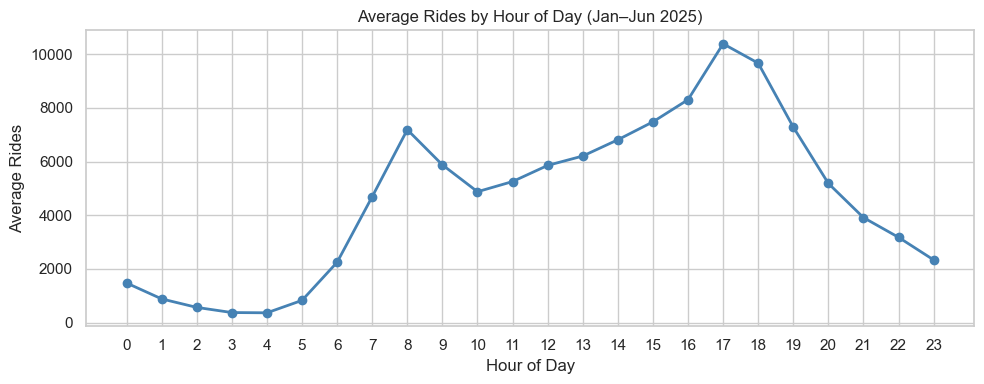

In [9]:
# ------------------------
# 1. Calculate average rides per hour
# ------------------------
hourly_avg = hourly['total'].groupby(level='hour').mean()

# ------------------------
# 2. Line plot
# ------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_avg.index, hourly_avg.values, color='steelblue', marker='o', linewidth=2)
ax.set_title('Average Rides by Hour of Day (Jan–Jun 2025)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Rides')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


## Step 8 · Peak Hours Identification

Identify the top morning and evening commute peak hours based on average ride volume.

Top morning peak hours:
hour
8    7,185.99
9    5,876.20
11   5,254.84
Name: total, dtype: float64

Top evening peak hours:
hour
17   10,385.04
18    9,664.12
16    8,303.82
Name: total, dtype: float64


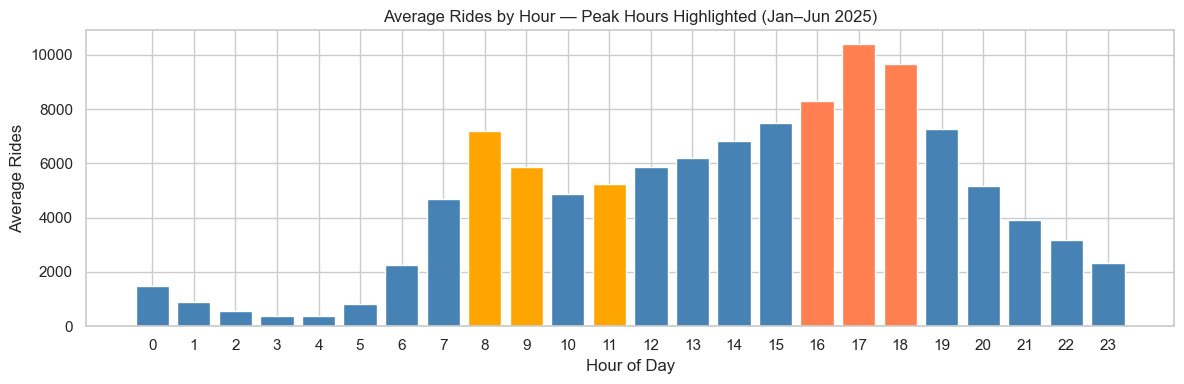

In [10]:
# ------------------------
# 1. Find top 3 morning peak hours (6am - 11am)
# ------------------------
morning = hourly_avg.loc[6:11]
morning_peak = morning.nlargest(3)
print('Top morning peak hours:')
print(morning_peak)

# ------------------------
# 2. Find top 3 evening peak hours (4pm - 9pm)
# ------------------------
evening = hourly_avg.loc[16:21]
evening_peak = evening.nlargest(3)
print('\nTop evening peak hours:')
print(evening_peak)

# ------------------------
# 3. Bar chart of all hours, highlight peaks
# ------------------------
colors = ['steelblue'] * 24
for h in morning_peak.index:
    colors[h] = 'orange'
for h in evening_peak.index:
    colors[h] = 'coral'

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color=colors)
ax.set_title('Average Rides by Hour — Peak Hours Highlighted (Jan–Jun 2025)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Rides')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


## Step 9 · Weekday-by-Hour Heatmap

Show the average ride volume for each combination of day of week and hour of day.

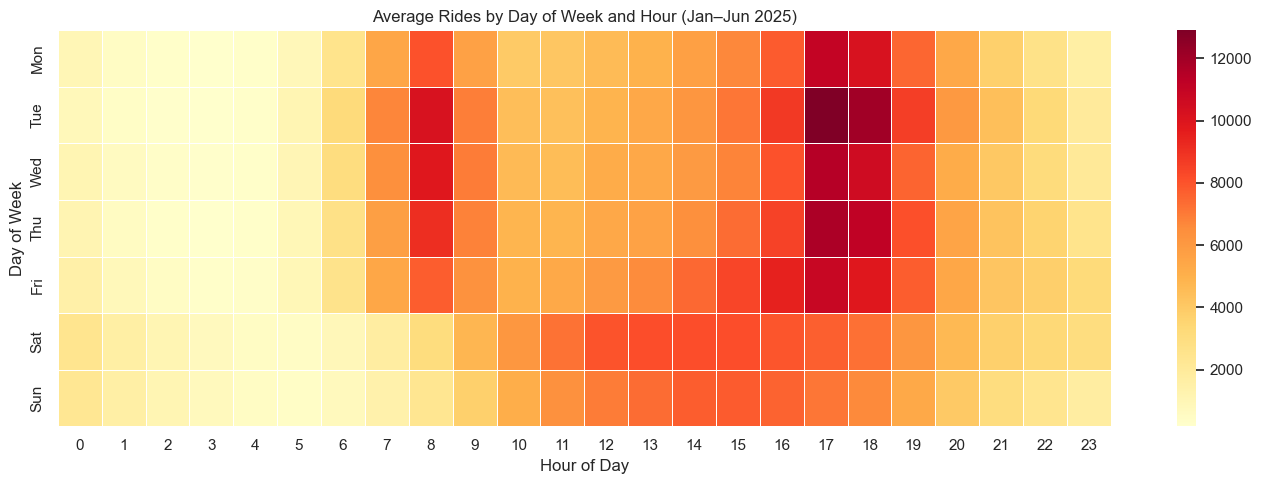

In [11]:
# ------------------------
# 1. Add day of week to hourly data
# ------------------------
hourly_reset = hourly.reset_index()
hourly_reset['weekday'] = hourly_reset['date'].dt.dayofweek

# ------------------------
# 2. Calculate average rides by weekday and hour
# ------------------------
heatmap_data = hourly_reset.groupby(['weekday', 'hour'])['total'].mean().unstack()

# Rename rows to day names
heatmap_data.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# ------------------------
# 3. Plot heatmap
# ------------------------
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average Rides by Day of Week and Hour (Jan–Jun 2025)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()


## Step 10 · Member vs Casual Usage Patterns

Compare how member and casual users ride differently by hour of day and by day of week. The first plot uses average hourly volume; the second uses average daily volume.


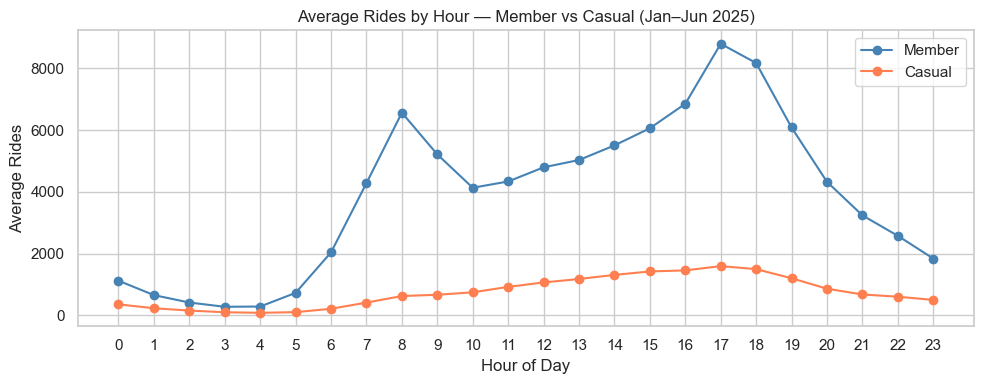

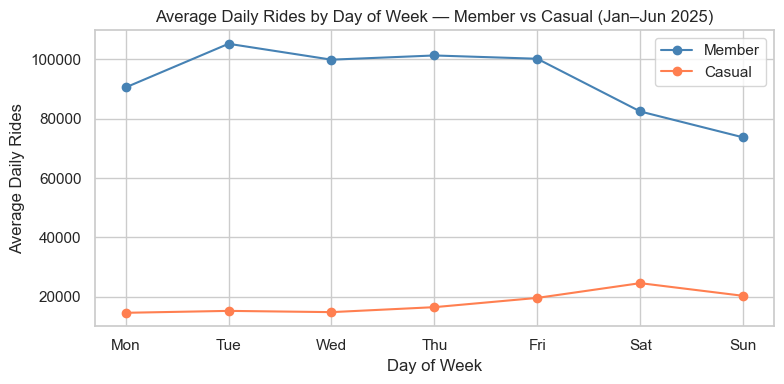

In [12]:
# ------------------------
# 1. Average rides by hour for each user type
# ------------------------
member_by_hour = hourly['member'].groupby(level='hour').mean()
casual_by_hour = hourly['casual'].groupby(level='hour').mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(member_by_hour.index, member_by_hour.values, color='steelblue', marker='o', label='Member')
ax.plot(casual_by_hour.index, casual_by_hour.values, color='coral', marker='o', label='Casual')
ax.set_title('Average Rides by Hour — Member vs Casual (Jan–Jun 2025)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Rides')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------
# 2. Average daily rides by day of week for each user type
# ------------------------
daily_by_user = daily.copy()
daily_by_user['weekday'] = daily_by_user.index.dayofweek

member_by_day = daily_by_user.groupby('weekday')['member'].mean()
casual_by_day = daily_by_user.groupby('weekday')['casual'].mean()

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(day_labels, member_by_day.values, color='steelblue', marker='o', label='Member')
ax.plot(day_labels, casual_by_day.values, color='coral', marker='o', label='Casual')
ax.set_title('Average Daily Rides by Day of Week — Member vs Casual (Jan–Jun 2025)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Daily Rides')
ax.legend()
plt.tight_layout()
plt.show()


# 5. Addressing the Question

## Step 11 · Create Forecasting Dataset

Use the cleaned daily ride counts as the forecasting dataset.

In [13]:
# ------------------------
# 1. Use daily total rides as the forecast target
# ------------------------
forecast_df = daily[['total']].copy()

print('Forecasting dataset shape:', forecast_df.shape)
print('Date range:', forecast_df.index.min().date(), 'to', forecast_df.index.max().date())
print()
print(forecast_df.head())


Forecasting dataset shape: (181, 1)
Date range: 2025-01-01 to 2025-06-30

            total
date             
2025-01-01  51442
2025-01-02  71779
2025-01-03  75361
2025-01-04  55389
2025-01-05  52177


## Step 12 · Add Time-Based Features

Add calendar features, lag features, and rolling averages to the forecasting dataset.

In [14]:
# ------------------------
# 1. Calendar features
# ------------------------
forecast_df['dayofweek'] = forecast_df.index.dayofweek
forecast_df['month']     = forecast_df.index.month
forecast_df['is_weekend'] = (forecast_df['dayofweek'] >= 5).astype(int)

# ------------------------
# 2. Lag features
# ------------------------
forecast_df['lag_1']  = forecast_df['total'].shift(1)
forecast_df['lag_7']  = forecast_df['total'].shift(7)

# ------------------------
# 3. Rolling average (7-day)
# ------------------------
forecast_df['rolling_7'] = forecast_df['total'].shift(1).rolling(window=7).mean()

# ------------------------
# 4. Drop rows with NaN (from lag/rolling)
# ------------------------
forecast_df = forecast_df.dropna()

print('Shape after adding features:', forecast_df.shape)
print(forecast_df.head())


Shape after adding features: (174, 7)
            total  dayofweek  month  is_weekend     lag_1     lag_7  rolling_7
date                                                                          
2025-01-08  66588          2      1           0 65,214.00 51,442.00  61,411.00
2025-01-09  67369          3      1           0 66,588.00 71,779.00  63,574.71
2025-01-10  81396          4      1           0 67,369.00 75,361.00  62,944.71
2025-01-11  64760          5      1           1 81,396.00 55,389.00  63,806.86
2025-01-12  69417          6      1           1 64,760.00 52,177.00  65,145.57


## Step 13 · Train / Test Split

Use January–May 2025 as training data and June 2025 as the test set.

In [15]:
# ------------------------
# 1. Split into train and test
# ------------------------
train = forecast_df[forecast_df.index < '2025-06-01']
test  = forecast_df[forecast_df.index >= '2025-06-01']

print('Train:', train.shape, '|', train.index.min().date(), 'to', train.index.max().date())
print('Test: ', test.shape,  '|', test.index.min().date(),  'to', test.index.max().date())


Train: (144, 7) | 2025-01-08 to 2025-05-31
Test:  (30, 7) | 2025-06-01 to 2025-06-30


## Step 14 · Baseline Models

Three simple baselines to compare against later models:
- **Moving Average**: predict using the 7-day rolling mean of the training set
- **Previous Day**: predict today = yesterday's actual
- **Previous Week Same Day**: predict today = same weekday one week ago

In [16]:
# ------------------------
# 1. Moving average baseline
#    Use the mean of the last 7 training days for every test day
# ------------------------
ma_value = train['total'].iloc[-7:].mean()
pred_ma  = [ma_value] * len(test)

# ------------------------
# 2. Previous-day baseline
#    Shift the full series by 1 day, then select test dates
# ------------------------
prev_day  = forecast_df['total'].shift(1)
pred_prev_day = prev_day.loc[test.index]

# ------------------------
# 3. Previous-week same-day baseline
#    Shift by 7 days
# ------------------------
prev_week     = forecast_df['total'].shift(7)
pred_prev_week = prev_week.loc[test.index]

# ------------------------
# 4. Quick check
# ------------------------
print('Moving average prediction (constant):', round(ma_value, 1))
print('Previous-day sample:')
print(pred_prev_day.head())
print('Previous-week sample:')
print(pred_prev_week.head())


Moving average prediction (constant): 141927.7
Previous-day sample:
date
2025-06-01   149,902.00
2025-06-02   140,189.00
2025-06-03   159,422.00
2025-06-04   179,950.00
2025-06-05   192,373.00
Name: total, dtype: float64
Previous-week sample:
date
2025-06-01   120,383.00
2025-06-02   140,952.00
2025-06-03   161,473.00
2025-06-04   102,595.00
2025-06-05   148,620.00
Name: total, dtype: float64


## Step 15 · Linear Regression Model

Train a linear regression using calendar and lag features, then predict the test set.

In [17]:
features = ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_7']

# ------------------------
# 1. Prepare X and y
# ------------------------
X_train = train[features]
y_train = train['total']
X_test  = test[features]
y_test  = test['total']

# ------------------------
# 2. Fit and predict
# ------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print('Linear regression trained.')
print('Sample predictions:', pred_lr[:5].round(0))


Linear regression trained.
Sample predictions: [141119. 154813. 164540. 168756. 177501.]


## Step 15B · ACF/PACF Diagnostics for ARIMA

Use first differencing to remove the strongest trend, then inspect ACF and PACF plots. These diagnostics motivate a simple ARIMA(1,1,1) specification for the rolling forecast.


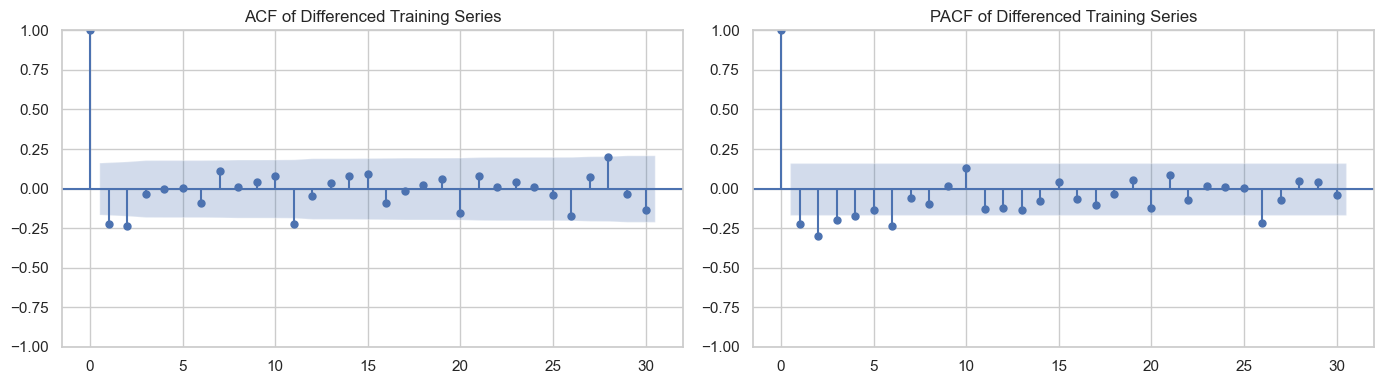

ARIMA order used for forecasting: (1, 1, 1)
d = 1 is used because the daily series has a clear upward trend over Jan-May.
p = 1 and q = 1 provide a simple specification consistent with short-lag dependence in the diagnostics.


In [18]:
# ------------------------
# 1. Difference the training series for ARIMA diagnostics
# ------------------------
arima_train = train["total"].asfreq("D")
arima_diff = arima_train.diff().dropna()

# ------------------------
# 2. Plot ACF and PACF
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(arima_diff, lags=30, ax=axes[0])
plot_pacf(arima_diff, lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Differenced Training Series")
axes[1].set_title("PACF of Differenced Training Series")
plt.tight_layout()
plt.show()

print("ARIMA order used for forecasting: (1, 1, 1)")
print("d = 1 is used because the daily series has a clear upward trend over Jan-May.")
print("p = 1 and q = 1 provide a simple specification consistent with short-lag dependence in the diagnostics.")


## Step 16 · ARIMA Model

Fit a rolling ARIMA(1,1,1) model using the one-step-ahead setup. For each June test date, the model is trained on all observations available up to the previous day, forecasts the next day, and then updates the history with the observed value. This makes ARIMA comparable to lag-based baselines and regression features.


In [19]:
# ------------------------
# 1. Rolling one-step-ahead ARIMA forecast
# ------------------------
history = train["total"].asfreq("D").copy()
pred_arima = []

for current_date in test.index:
    arima_model = ARIMA(history.asfreq("D"), order=(1, 1, 1))
    arima_result = arima_model.fit()
    next_forecast = arima_result.forecast(steps=1).iloc[0]
    pred_arima.append(next_forecast)

    # After forecasting this date, reveal the observed value for the next step.
    history.loc[current_date] = test.loc[current_date, "total"]

pred_arima = np.array(pred_arima)

print("Rolling ARIMA(1,1,1) fitted.")
print("Sample forecast:", pred_arima[:5].round(0))


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/

Rolling ARIMA(1,1,1) fitted.
Sample forecast: [143824. 139567. 149280. 160853. 169697.]


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## Step 17 · Model Evaluation

Compare all models using MAE, MSE, and RMSE on the June 2025 test set under the same one-step-ahead evaluation setup. Also plot actual vs predicted rides and check residual behavior for the best model.


                           MAE              MSE      RMSE
Model                                                    
Linear Regression    15,255.50   432,417,936.30 20,794.70
Rolling ARIMA(1,1,1) 18,970.20   650,766,883.80 25,510.10
Previous Day         19,929.20   820,722,316.20 28,648.30
Previous Week        23,669.20 1,036,221,201.50 32,190.40
Moving Average       25,207.30   931,315,521.50 30,517.50


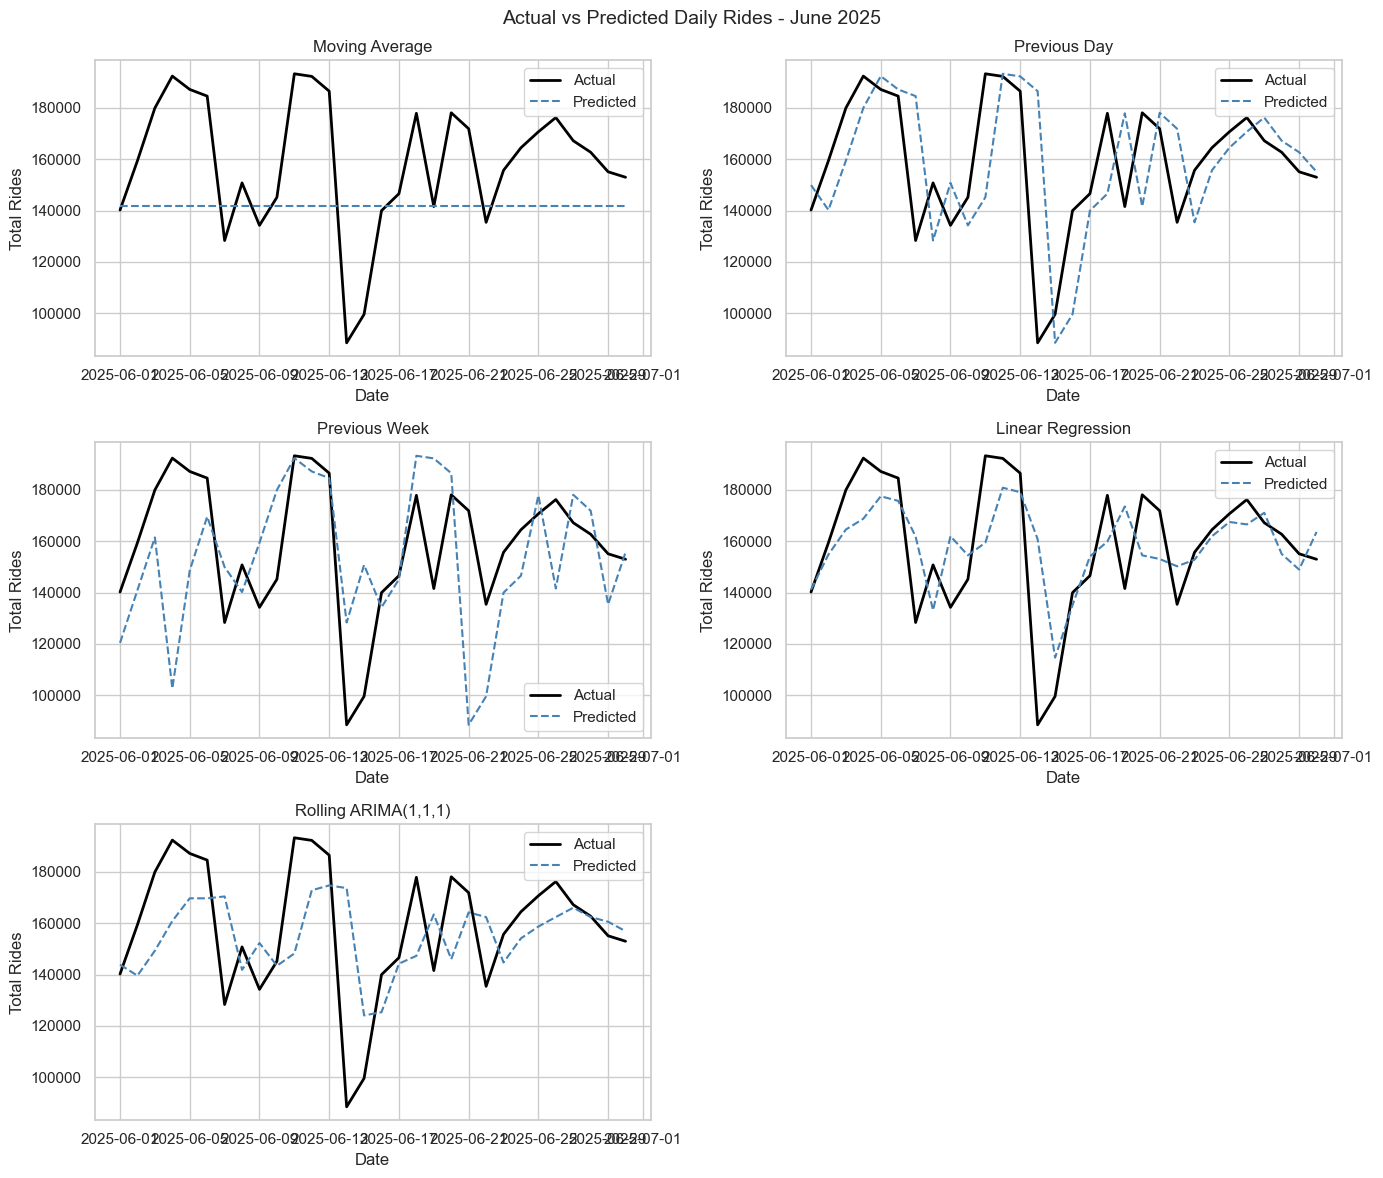

Best model by MAE: Linear Regression
Residual mean: 76.0
Residual std : 21150.0
Residuals outside +/-3 sigma: 1
Dates outside +/-3 sigma: [datetime.date(2025, 6, 14)]


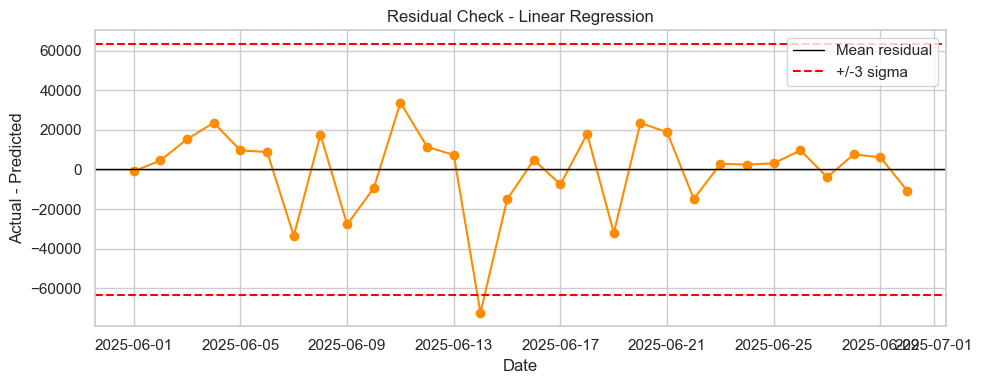

In [20]:
y_true = test["total"].values

# ------------------------
# 1. Compute metrics for each model
# ------------------------
def eval_model(name, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"Model": name, "MAE": round(mae, 1), "MSE": round(mse, 1), "RMSE": round(rmse, 1)}

model_predictions = {
    "Moving Average": np.array(pred_ma),
    "Previous Day": pred_prev_day.values,
    "Previous Week": pred_prev_week.values,
    "Linear Regression": pred_lr,
    "Rolling ARIMA(1,1,1)": pred_arima,
}

results = [eval_model(name, pred) for name, pred in model_predictions.items()]
results_df = pd.DataFrame(results).set_index("Model").sort_values("MAE")
print(results_df.to_string())

# ------------------------
# 2. Plot actual vs predicted: one subplot per model
# ------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, pred) in enumerate(model_predictions.items()):
    axes[i].plot(test.index, y_true, label="Actual", color="black", linewidth=2)
    axes[i].plot(test.index, pred, label="Predicted", color="steelblue", linestyle="--")
    axes[i].set_title(name)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Total Rides")
    axes[i].legend()

axes[5].set_visible(False)

plt.suptitle("Actual vs Predicted Daily Rides - June 2025", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------
# 3. Residual sanity check for the best model
# ------------------------
best_model_name = results_df.index[0]
best_pred = model_predictions[best_model_name]
residuals = pd.Series(y_true - best_pred, index=test.index, name="residual")
residual_mean = residuals.mean()
residual_std = residuals.std()
outside_3sigma = residuals[np.abs(residuals - residual_mean) > 3 * residual_std]

print("Best model by MAE:", best_model_name)
print("Residual mean:", round(residual_mean, 1))
print("Residual std :", round(residual_std, 1))
print("Residuals outside +/-3 sigma:", len(outside_3sigma))
if len(outside_3sigma) > 0:
    print("Dates outside +/-3 sigma:", list(outside_3sigma.index.date))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(residuals.index, residuals, marker="o", color="darkorange")
ax.axhline(residual_mean, color="black", linewidth=1, label="Mean residual")
ax.axhline(residual_mean + 3 * residual_std, color="red", linestyle="--", label="+/-3 sigma")
ax.axhline(residual_mean - 3 * residual_std, color="red", linestyle="--")
ax.set_title(f"Residual Check - {best_model_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Actual - Predicted")
ax.legend()
plt.tight_layout()
plt.show()
